In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Load date and display the data head
from google.colab import drive
# Will ask for authentication, click allow
drive.mount("/content/drive")

# Enter the correct path here
#------YOUR CODE HERE--------

%cd '/content/drive/My Drive'

#------YOUR CODE ENDS--------

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.chdir("/content/drive/MyDrive")

stats = pd.read_csv('Seasons_Stats.csv')
players = pd.read_csv('Players.csv')

stats = pd.merge(stats,players, left_on = 'Player', right_on = 'Player')


#Only use the modern nba and cut out the 2017 season so we can use it for test
stats_test = stats[stats['Year'] == 2017]
stats = stats[stats['Year'] >= 2006]

#Make sure everybody in the data has played enough games to the point where they aren't a major outlier for one great game out of about 3 played.
stats_test = stats_test[stats_test['G'] > 15]
stats = stats[stats['G'] > 15]

stats = stats[stats['MP'] > 10]
stats_test = stats_test[stats_test['MP'] > 10]

stats = stats[stats['Tm'] != 'TOT']

## We want to make these stats adjusted for players playing the same amount of time for the clustering, because we want to make sure that we are not makingthe archetypes based on who is a more effective player.
per36_stats = ['PTS', 'AST', 'TRB', 'STL', 'BLK', 'FGA', 'FG', 'FTA', 'FT', '3PA', '3P', '2P', '2PA']

for stat in per36_stats:
    stats[stat + "_per36"] = stats[stat] / stats['MP'] * 36

for stat in per36_stats:
    stats_test[stat + "_per36"] = stats[stat] / stats['MP'] * 36

pd.set_option('display.max_columns', None)

stats.head()

Mounted at /content/drive
/content/drive/My Drive


,Unnamed: 0_x,Year,Player,Pos,Age,Tm,G,GS,MP,PER,TS%,3PAr,FTr,ORB%,DRB%,TRB%,AST%,STL%,BLK%,TOV%,USG%,blanl,OWS,DWS,WS,WS/48,blank2,OBPM,DBPM,BPM,VORP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Unnamed: 0_y,height,weight,collage,born,birth_city,birth_state,PTS_per36,AST_per36,TRB_per36,STL_per36,BLK_per36,FGA_per36,FG_per36,FTA_per36,FT_per36,3PA_per36,3P_per36,2P_per36,2PA_per36
17662,17662,2006.0,Shareef Abdur-Rahim,PF,29.0,SAC,72.0,30.0,1961.0,17.2,0.588,0.035,0.440,6.4,14.8,10.6,13.2,1.3,1.6,12.5,20.1,NaN,4.0,2.2,6.2,0.152,NaN,0.4,0.4,0.9,1.4,332.0,632.0,0.525,5.0,22.0,0.227,327.0,610.0,0.536,0.529,218.0,278.0,0.784,106.0,251.0,357.0,149.0,48.0,42.0,108.0,227.0,887.0,2449,206.0,102.0,University of California,1976.0,Marietta,Georgia,16.283529,2.735339,6.553799,0.881183,0.771035,11.602244,6.094850,5.103519,4.002040,0.403876,0.091790,6.003060,11.198368
17664,17664,2006.0,Malik Allen,PF,27.0,CHI,54.0,20.0,701.0,11.5,0.504,0.004,0.154,7.2,15.7,11.5,4.9,1.0,1.8,11.4,19.2,NaN,0.0,1.0,1.0,0.068,NaN,-3.9,0.0,-3.9,-0.3,121.0,247.0,0.490,1.0,1.0,1.000,120.0,246.0,0.488,0.492,23.0,38.0,0.605,44.0,96.0,140.0,20.0,14.0,16.0,34.0,92.0,266.0,2776,208.0,115.0,Villanova University,1978.0,Willingboro,New Jersey,13.660485,1.027104,7.189729,0.718973,0.821683,12.684736,6.213980,1.951498,1.181170,0.051355,0.051355,6.162625,12.633381
17665,17665,2006.0,Ray Allen,SG,30.0,SEA,78.0,78.0,3022.0,22.2,0.590,0.435,0.239,2.8,10.6,6.6,17.2,1.8,0.4,10.2,27.4,NaN,9.8,-0.3,9.5,0.150,NaN,6.7,-3.1,3.6,4.2,681.0,1500.0,0.454,269.0,653.0,0.412,412.0,847.0,0.486,0.544,324.0,359.0,0.903,71.0,261.0,332.0,286.0,105.0,16.0,188.0,151.0,1955.0,2450,203.0,99.0,Florida State University,1965.0,Milton,Florida,23.289212,3.407015,3.954997,1.250827,0.190602,17.868961,8.112508,4.276638,3.859696,7.778954,3.204500,4.908008,10.090007
17666,17666,2006.0,Tony Allen,PG,24.0,BOS,51.0,9.0,978.0,12.9,0.554,0.124,0.489,4.1,9.6,6.9,11.2,2.7,1.4,16.8,18.8,NaN,0.6,1.0,1.7,0.082,NaN,-1.6,0.2,-1.4,0.2,129.0,274.0,0.471,11.0,34.0,0.324,118.0,240.0,0.492,0.491,100.0,134.0,0.746,32.0,79.0,111.0,67.0,51.0,18.0,67.0,126.0,369.0,2974,193.0,96.0,Oklahoma State University,1982.0,Chicago,Illinois,13.582822,2.466258,4.085890,1.877301,0.662577,10.085890,4.748466,4.932515,3.680982,1.251534,0.404908,4.343558,8.834356
17667,17667,2006.0,Rafer Alston,PG,29.0,HOU,63.0,63.0,2431.0,12.6,0.475,0.423,0.194,1.8,10.4,6.1,30.8,2.3,0.5,16.4,18.8,NaN,0.2,3.1,3.4,0.067,NaN,0.1,0.7,0.8,1.7,280.0,738.0,0.379,102.0,312.0,0.327,178.0,426.0,0.418,0.449,99.0,143.0,0.692,36.0,219.0,255.0,425.0,101.0,15.0,157.0,194.0,761.0,2648,188.0,77.0,"California State University, Fresno",1976.0,New York,New York,11.269436,6.293706,3.776224,1.495681,0.222131,10.928836,4.146442,2.117647,1.466063,4.620321,1.510490,2.635952,6.308515


In [ ]:
## Using our industry expertise we believe these will have no impact on an individual player valuation so eliminate them for simplicity
stats = stats.drop(columns = ['Unnamed: 0_x', 'Unnamed: 0_y', 'collage', 'born', 'birth_city', 'birth_state', 'blanl','blank2', 'Tm', 'Player', 'G', 'GS', 'MP','Pos'])

In [ ]:
stats.head()

,Year,Age,PER,TS%,3PAr,FTr,ORB%,DRB%,TRB%,AST%,STL%,BLK%,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,height,weight,PTS_per36,AST_per36,TRB_per36,STL_per36,BLK_per36,FGA_per36,FG_per36,FTA_per36,FT_per36,3PA_per36,3P_per36,2P_per36,2PA_per36
17662,2006.0,29.0,17.2,0.588,0.035,0.440,6.4,14.8,10.6,13.2,1.3,1.6,12.5,20.1,4.0,2.2,6.2,0.152,0.4,0.4,0.9,1.4,332.0,632.0,0.525,5.0,22.0,0.227,327.0,610.0,0.536,0.529,218.0,278.0,0.784,106.0,251.0,357.0,149.0,48.0,42.0,108.0,227.0,887.0,206.0,102.0,16.283529,2.735339,6.553799,0.881183,0.771035,11.602244,6.094850,5.103519,4.002040,0.403876,0.091790,6.003060,11.198368
17664,2006.0,27.0,11.5,0.504,0.004,0.154,7.2,15.7,11.5,4.9,1.0,1.8,11.4,19.2,0.0,1.0,1.0,0.068,-3.9,0.0,-3.9,-0.3,121.0,247.0,0.490,1.0,1.0,1.000,120.0,246.0,0.488,0.492,23.0,38.0,0.605,44.0,96.0,140.0,20.0,14.0,16.0,34.0,92.0,266.0,208.0,115.0,13.660485,1.027104,7.189729,0.718973,0.821683,12.684736,6.213980,1.951498,1.181170,0.051355,0.051355,6.162625,12.633381
17665,2006.0,30.0,22.2,0.590,0.435,0.239,2.8,10.6,6.6,17.2,1.8,0.4,10.2,27.4,9.8,-0.3,9.5,0.150,6.7,-3.1,3.6,4.2,681.0,1500.0,0.454,269.0,653.0,0.412,412.0,847.0,0.486,0.544,324.0,359.0,0.903,71.0,261.0,332.0,286.0,105.0,16.0,188.0,151.0,1955.0,203.0,99.0,23.289212,3.407015,3.954997,1.250827,0.190602,17.868961,8.112508,4.276638,3.859696,7.778954,3.204500,4.908008,10.090007
17666,2006.0,24.0,12.9,0.554,0.124,0.489,4.1,9.6,6.9,11.2,2.7,1.4,16.8,18.8,0.6,1.0,1.7,0.082,-1.6,0.2,-1.4,0.2,129.0,274.0,0.471,11.0,34.0,0.324,118.0,240.0,0.492,0.491,100.0,134.0,0.746,32.0,79.0,111.0,67.0,51.0,18.0,67.0,126.0,369.0,193.0,96.0,13.582822,2.466258,4.085890,1.877301,0.662577,10.085890,4.748466,4.932515,3.680982,1.251534,0.404908,4.343558,8.834356
17667,2006.0,29.0,12.6,0.475,0.423,0.194,1.8,10.4,6.1,30.8,2.3,0.5,16.4,18.8,0.2,3.1,3.4,0.067,0.1,0.7,0.8,1.7,280.0,738.0,0.379,102.0,312.0,0.327,178.0,426.0,0.418,0.449,99.0,143.0,0.692,36.0,219.0,255.0,425.0,101.0,15.0,157.0,194.0,761.0,188.0,77.0,11.269436,6.293706,3.776224,1.495681,0.222131,10.928836,4.146442,2.117647,1.466063,4.620321,1.510490,2.635952,6.308515


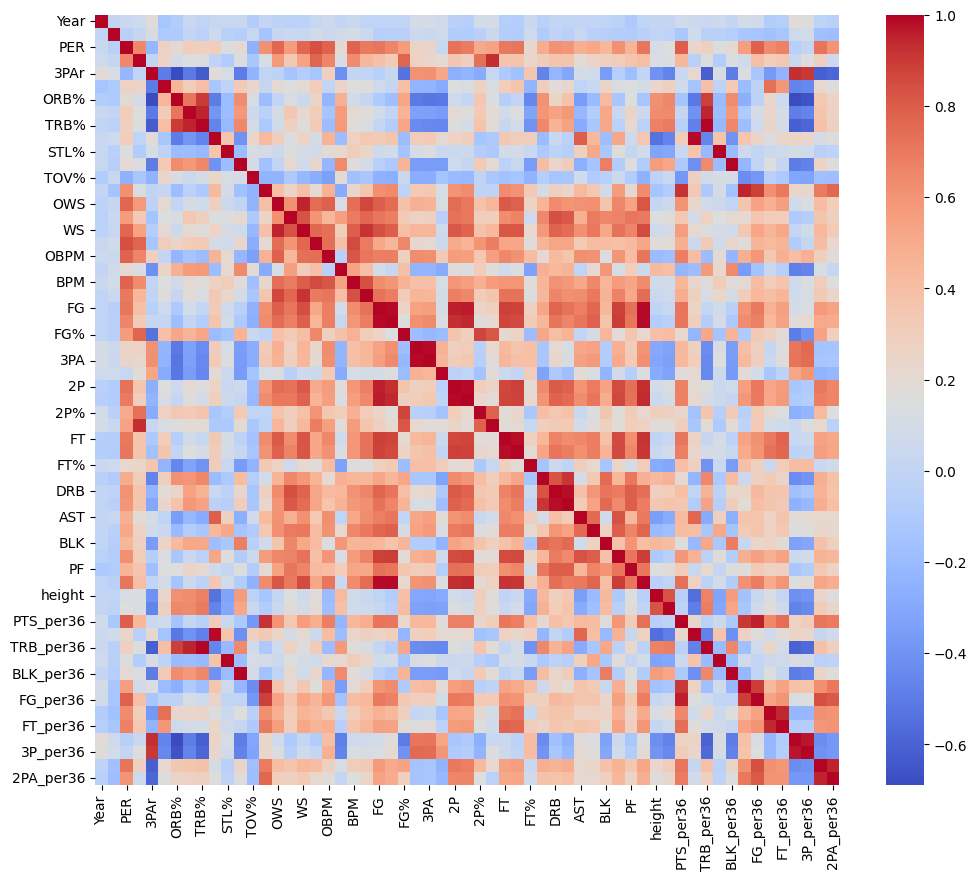

In [ ]:
## Assess which variables are correlated to eachother
corr = stats.corr()
plt.figure(figsize = (12,10))
sns.heatmap(corr, annot = False, cmap = 'coolwarm')
plt.show()

In [ ]:
# This is the metric we are kind of aiming to mimic and improve upon, so we want to see what correlates
print(corr['VORP'].sort_values(ascending=False))

VORP         1.000000
WS           0.915759
OWS          0.865592
BPM          0.837909
DWS          0.768324
PTS          0.745834
FG           0.726741
FT           0.726652
FTA          0.725685
OBPM         0.716160
STL          0.709562
PER          0.702362
WS/48        0.695632
FGA          0.689244
2P           0.680449
TOV          0.668209
DRB          0.661298
2PA          0.647761
AST          0.626455
TRB          0.619110
PF           0.512074
PTS_per36    0.488346
BLK          0.460241
FT_per36     0.449678
3P           0.446087
ORB          0.445568
3PA          0.443383
TS%          0.442256
FG_per36     0.436097
DBPM         0.401519
FTA_per36    0.400977
eFG%         0.361834
USG%         0.356863
AST%         0.336845
2P_per36     0.336272
2P%          0.318383
FG%          0.303497
FGA_per36    0.301623
AST_per36    0.286677
STL%         0.245573
2PA_per36    0.244055
STL_per36    0.243281
DRB%         0.181061
FTr          0.166997
FT%          0.159910
TRB%      

In [ ]:
### Some of the variables are not going to hae values becuase the prcentage is undefined so we set these to a 0% for consistency purposes

stats['3P%'] = stats['3P%'].fillna(0)
stats['2P%'] = stats['2P%'].fillna(0)
stats['FT%'] = stats['FT%'].fillna(0)

stats.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5269 entries, 17662 to 24690
Data columns (total 59 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Year       5269 non-null   float64
 1   Age        5269 non-null   float64
 2   PER        5269 non-null   float64
 3   TS%        5269 non-null   float64
 4   3PAr       5269 non-null   float64
 5   FTr        5269 non-null   float64
 6   ORB%       5269 non-null   float64
 7   DRB%       5269 non-null   float64
 8   TRB%       5269 non-null   float64
 9   AST%       5269 non-null   float64
 10  STL%       5269 non-null   float64
 11  BLK%       5269 non-null   float64
 12  TOV%       5269 non-null   float64
 13  USG%       5269 non-null   float64
 14  OWS        5269 non-null   float64
 15  DWS        5269 non-null   float64
 16  WS         5269 non-null   float64
 17  WS/48      5269 non-null   float64
 18  OBPM       5269 non-null   float64
 19  DBPM       5269 non-null   float64
 20  BPM     

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples

## Prepare our data to be used in a regression model, VORP is what we're trying to emulate right now so we don't necessarily want it impacting our statistic.
## These stats are metrics of overall player perfomance so we want to eliminate them so we can capture player performance and style not overall talent.
## Eliminating some counting stats so we don't cluster players based on performance and jsut play styles
X = stats.drop(columns = ['VORP', 'BPM', 'WS', 'WS/48', 'OWS', 'DWS', 'OBPM', 'DBPM', 'PER', 'PTS', 'FG', 'FT', 'FTA', '2P', '2PA', '3P', '3PA', 'Year', 'Age', 'AST', 'TRB', 'STL', 'BLK', 'FGA'])
X = X.drop(columns = ['TS%', '3PAr', 'FTr', 'ORB%', 'DRB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%', 'eFG%', 'ORB', 'DRB', 'TOV', 'PF', '2PA_per36'])
y = stats['VORP']

#Because stats like points are a much higher number than steals, we want this to be neutralized so scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X)


In [ ]:
X.head()

,FG%,3P%,2P%,FT%,height,weight,PTS_per36,AST_per36,TRB_per36,STL_per36,BLK_per36,FGA_per36,FG_per36,FTA_per36,FT_per36,3PA_per36,3P_per36,2P_per36
17662,0.525,0.227,0.536,0.784,206.0,102.0,16.283529,2.735339,6.553799,0.881183,0.771035,11.602244,6.094850,5.103519,4.002040,0.403876,0.091790,6.003060
17664,0.490,1.000,0.488,0.605,208.0,115.0,13.660485,1.027104,7.189729,0.718973,0.821683,12.684736,6.213980,1.951498,1.181170,0.051355,0.051355,6.162625
17665,0.454,0.412,0.486,0.903,203.0,99.0,23.289212,3.407015,3.954997,1.250827,0.190602,17.868961,8.112508,4.276638,3.859696,7.778954,3.204500,4.908008
17666,0.471,0.324,0.492,0.746,193.0,96.0,13.582822,2.466258,4.085890,1.877301,0.662577,10.085890,4.748466,4.932515,3.680982,1.251534,0.404908,4.343558
17667,0.379,0.327,0.418,0.692,188.0,77.0,11.269436,6.293706,3.776224,1.495681,0.222131,10.928836,4.146442,2.117647,1.466063,4.620321,1.510490,2.635952


Components needed for 90% variance: 8
Components needed for 95% variance: 10
Components needed for 99% variance: 12


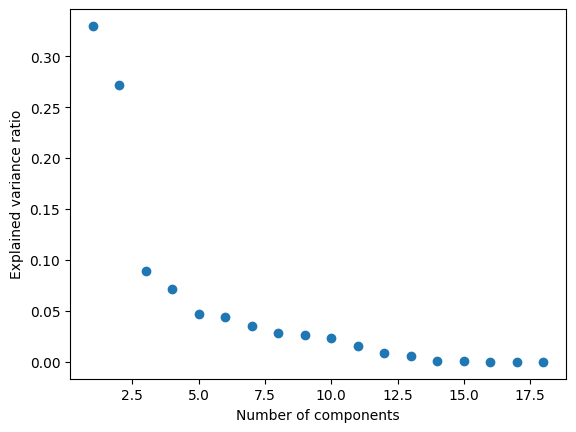

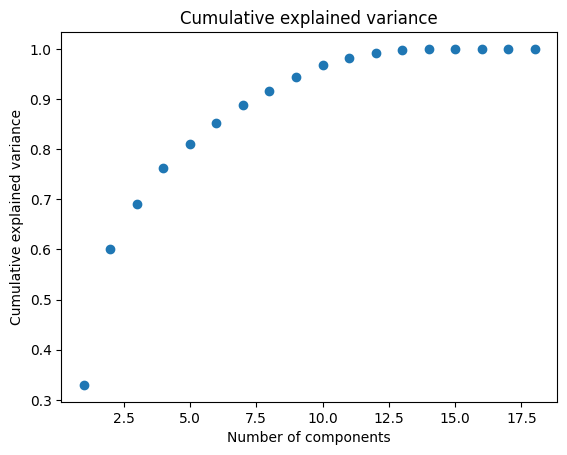

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Fit PCA on the scaled data
pca = PCA()
pca.fit(X_train)

# Explained variance ratio
evr = pca.explained_variance_ratio_

# plot # of components vs the variance ratio
# plot evr from x=1
plt.plot(range(1, len(evr) + 1),evr,'o')
# x axis
plt.xlabel('Number of components')
# y axis
plt.ylabel('Explained variance ratio')
#

# Calculate cumulative explained variance
cev = np.cumsum(evr)


# Plot cumulative explained variance
plt.figure()
plt.plot(range(1, len(cev) + 1),cev,'o')
plt.title('Cumulative explained variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')

# Find number of components needed for each threshold

thresholds = [0.90, 0.95, 0.99]

for t in thresholds:
    n_components = np.argmax(cev >= t) + 1  # +1 because index starts at 0
    print(f"Components needed for {int(t*100)}% variance: {n_components}")


In [ ]:
## Due to lack of components use the .99 values
pca = PCA(n_components=0.99)
X_pca = pca.fit_transform(X_train)

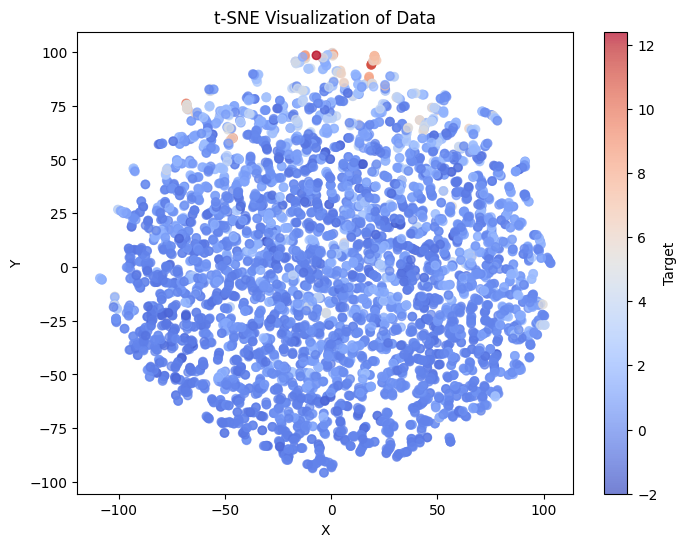

In [ ]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


tsne = TSNE(random_state=42, perplexity=5)

X_tsne = tsne.fit_transform(X_pca)


plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("t-SNE Visualization of Data")
plt.colorbar(scatter, label="Target")
plt.show()

We can see that mini clusters do form in the data that kind of look like church pews. We also see that the values get brighter as we move to the riight indicating that there are certainly patterns and clusters in the data.

Best k: 2
Best silhouette score: 0.2553243448399827


array([1, 3, 4, ..., 6, 5, 1], dtype=int32)

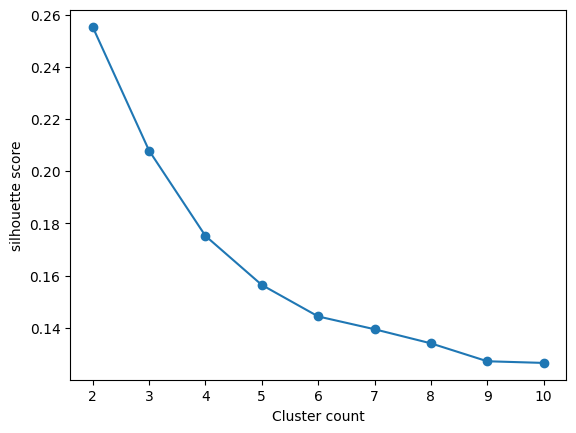

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Use the silhouette score method to determine the best number of clusters to use for our clustering methods
silhouettes = []
k_values = range(2,11)


## Run the kmeans clustering function for all the different k values and then determine which k value we are going to use
for k in range(2,11):
  kmeans = KMeans(n_clusters=k, random_state = 42, init = 'k-means++', n_init = "auto")
  cluster_labels = kmeans.fit_predict(X_pca)
  score = silhouette_score(X_pca, cluster_labels)
  silhouettes.append(score)


## Plot and find out the k values with their respective silhouette scores
best_k = k_values[np.argmax(silhouettes)]
best_score = max(silhouettes)

print("Best k:", best_k)
print("Best silhouette score:", best_score)


plt.plot(k_values, silhouettes, marker='o')
plt.xlabel('Cluster count')
plt.ylabel('silhouette score')
plt.show

cluster_labels

We are going to be using the k value of 8 because even though it has a worse silhouette score than clusters 2 and 3, we want to be able to cluster the players into better groups than good and bad players. This will align with the amount of basketball positions and archetypes that we had in mind going into the project so we are pleased with this view.

In [ ]:
best_k = 6

In [ ]:
# Run our kmeans baseline with the best k clusters and give the clusters to the entirety of the data

kmeans = KMeans(n_clusters=best_k, random_state = 0, n_init = "auto").fit(X_pca)
y = kmeans.predict(X_pca)
clusters = kmeans.labels_

# Find out what the centers are for the individual clusters in our data set
original_centers = pca.inverse_transform(kmeans.cluster_centers_)
centers = pd.DataFrame(
    original_centers,
    columns=X.columns,
    index=[f"Cluster {i}" for i in range(best_k)]
)

In [ ]:
## find a way to value the clusters in another manner and interpret the clusters in a manner that isn't silhouette score
from sklearn.metrics import davies_bouldin_score

davies_score = davies_bouldin_score(X_pca, clusters)
print("Davies-Bouldin Score:", davies_score)


Davies-Bouldin Score: 1.8603033840045813


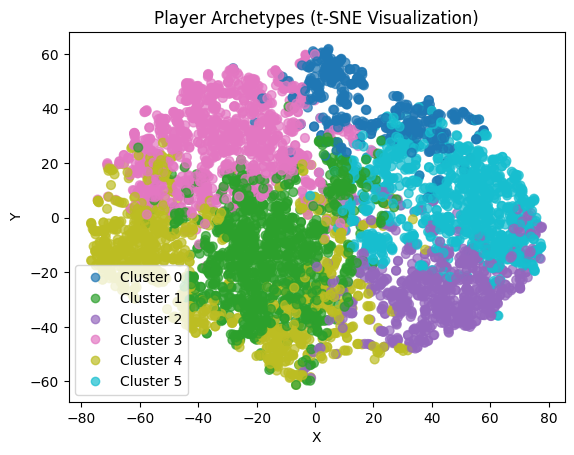

In [ ]:
## visualize our tsne so we can see the clusters in action adn determine the patterns

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_pca)



scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=clusters,
    cmap='tab10',
    alpha=0.7,
    s=40
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Player Archetypes (t-SNE Visualization)")
plt.legend(handles=scatter.legend_elements()[0], labels=[f"Cluster {i}" for i in range(best_k)])
plt.show()

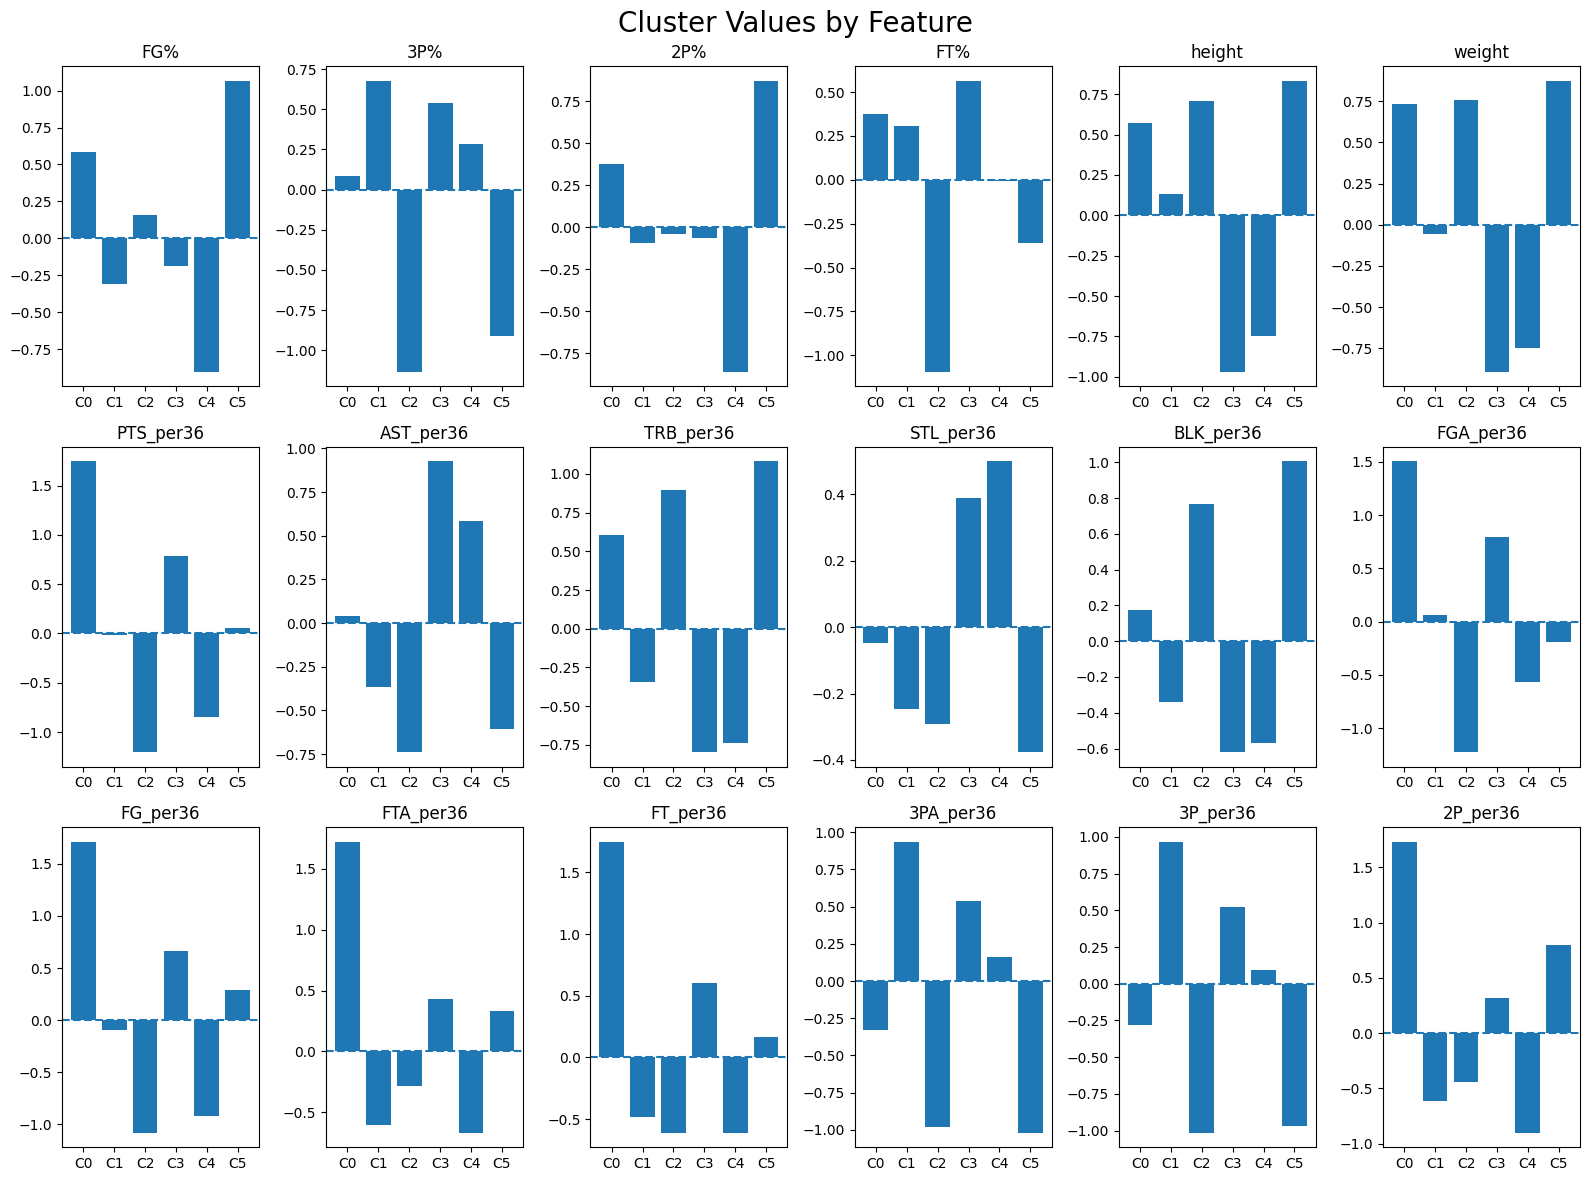

In [ ]:
import matplotlib.pyplot as plt
import math

## Plot out all of the different clusters so we can identify which features they value the most.
features = centers.columns
n_features = len(features)

ncols = 6
nrows = math.ceil(n_features / ncols)


## Plot the individual columns one at a time so we have this clear view
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]

    values = centers[feature]

    ax.bar(range(len(values)), values)
    ax.set_title(feature)
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels([f"C{j}" for j in range(len(values))])
    ax.axhline(0, linestyle='--')

# remove extra plots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Cluster Values by Feature", fontsize=20)
plt.tight_layout()
plt.show()

In [ ]:
print(centers.to_string())

                FG%       3P%       2P%       FT%    height    weight  PTS_per36  AST_per36  TRB_per36  STL_per36  BLK_per36  FGA_per36  FG_per36  FTA_per36  FT_per36  3PA_per36  3P_per36  2P_per36
Cluster 0  0.587758  0.082786  0.375267  0.377174  0.574899  0.731838   1.744877   0.042980   0.605281  -0.047250   0.175576   1.503331  1.708213   1.721158  1.746038  -0.327496 -0.280886  1.729377
Cluster 1 -0.311074  0.677035 -0.091953  0.304549  0.135009 -0.055102  -0.014976  -0.366948  -0.346958  -0.245113  -0.341324   0.065266 -0.096853  -0.606834 -0.480538   0.934287  0.965401 -0.619278
Cluster 2  0.158817 -1.132697 -0.037530 -1.092438  0.706007  0.755138  -1.203855  -0.739343   0.893403  -0.291503   0.765232  -1.225542 -1.080019  -0.286558 -0.609977  -0.983118 -1.014636 -0.438913
Cluster 3 -0.184668  0.541469 -0.066583  0.563783 -0.968340 -0.891223   0.787368   0.924998  -0.797508   0.388340  -0.620443   0.792344  0.658424   0.432130  0.601905   0.540881  0.525263  0.318798
Cluster 4 

In [ ]:
# -----------------------------
# GEMINI PROMPT FOR NBA CLUSTER LABELING
# -----------------------------


### This chunk of text and the gemini prompt were built using gemini online itself.
# First create one big text block containing all cluster summaries
cluster_text = ""

for cluster in centers.index:
    row = centers.loc[cluster]

    top_positive = row.sort_values(ascending=False).head(5)
    top_negative = row.sort_values().head(5)

    cluster_text += f"\n{cluster}\n"
    cluster_text += "Top positive features:\n"
    cluster_text += top_positive.to_string()
    cluster_text += "\nTop negative features:\n"
    cluster_text += top_negative.to_string()
    cluster_text += "\n\n"


# Build Gemini prompt
prompt = f"""
You are an NBA analytics expert helping interpret clustering results from a machine learning project.

I used KMeans clustering on NBA player season data to identify player archetypes.
These clusters were created using standardized NBA statistics after PCA dimensionality reduction.

Important interpretation notes:
- Positive values mean above league average.
- Negative values mean below league average.
- Features like AST, USG%, PTS, TRB, BLK, STL, 3PA, height, and weight are especially useful for interpretation.

Your task:
For EACH cluster:
1. Assign a short archetype name (2–5 words).
2. Explain why that label fits.
3. Describe the typical offensive role.
4. Describe the typical defensive role.
5. Assign a value tier:
   - High-value
   - Medium-value
   - Lower-value
6. Rank the clusters in order of value

Return results clearly labeled cluster by cluster.

Here are the cluster summaries:

{cluster_text}
"""


# -----------------------------
# SEND TO GEMINI
# -----------------------------
response = client.models.generate_content(
    model=MODEL_ID,
    contents=prompt
)

print(response.text)

As an NBA analytics expert, I've reviewed your KMeans clustering results to identify player archetypes. The standardized statistics and PCA dimensionality reduction provide a clear view of how these players differ from the league average.

Here's my interpretation for each cluster, along with a value tier and a final ranking:

---

### **Cluster 0: Interior Scorer & Finisher**

1.  **Archetype Name:** Interior Scorer & Finisher
2.  **Explanation:** This archetype is characterized by exceptionally high volume and efficiency in scoring close to the basket. Their top positive features (PTS, 2P, FT, FTA, FG per 36 minutes) are all significantly above average, indicating a player who consistently gets to the rim or operates in the post, draws fouls, and finishes efficiently. The strong negative values for 3PA and 3P per 36 confirm they are not a three-point threat.
3.  **Offensive Role:** Primary scoring option, often operating from the paint or mid-range. They are adept at driving, posting

Cluster 0 - Rim protectors (Mid)
cluster 1 - Playmakers (Good)
cluster 2 - 3 and D Wings (Good)
Cluster 3 - Offensive Engines (Good)
cluster 4 - Inefficient Scorers (Bad)
cluster 5 - Paint Beasts (Good)
cluster 6 - Physical Forwards (Mid)
cluster 7 - 3 point sharp shooters (no Defense) (Good)